# Notebook 7 -- Hyperparameter Tuning and Model Selection

**Goal:** improve the best classical models using reproducible hyperparameter search.

This notebook focuses on tree-based models because they handle nonlinear tabular interactions well and usually perform strongly on structured agricultural datasets.

Results:

- tuned model metrics,
- best hyperparameters,
- a saved best-model artifact,
- model comparison plots.

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "07_hyperparameter_tuning_and_model_selection"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 7.1 Loading data, config, and ML tools

In [2]:
import yaml
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform, loguniform

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from nigeria_crop_yield.models.train import make_preprocessor, split_data

CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

modeling_df = pd.read_csv(PROCESSED_DIR / "modeling_dataset.csv")
TARGET = config["nbs"].get("target", "yield_kg_ha")
LEAKAGE_COLUMNS = set(config["modeling"].get("leakage_columns", []))
numeric_features = [c for c in config["modeling"].get("numeric_features", []) if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
categorical_features = [c for c in config["modeling"].get("categorical_features", []) if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
feature_cols = numeric_features + categorical_features

modeling_df = modeling_df[modeling_df[TARGET].notna()].copy()
train_df, test_df = split_data(modeling_df, target=TARGET, test_size=0.25, random_state=RANDOM_STATE, group_col="state")
X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]
groups_train = train_df["state"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Features:", feature_cols)

Train: (368, 15) Test: (122, 15)
Features: ['households_reporting_000', 'planted_area_ha', 'latitude', 'longitude', 'total_rainfall_mm', 'mean_tmean_c', 'mean_tmax_c', 'mean_tmin_c', 'mean_rh_percent', 'growing_degree_days', 'heat_stress_days', 'crop', 'season', 'zone', 'agroecological_zone']


## 7.2 Defining search spaces

The search is intentionally moderate so it can run on a laptop.  We can increase `N_ITER` if there is more time.

In [3]:
N_ITER = 15
N_SPLITS = min(5, train_df["state"].nunique())
cv = GroupKFold(n_splits=N_SPLITS)
preprocessor = make_preprocessor(numeric_features, categorical_features)

search_spaces = {
    "random_forest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "model__n_estimators": randint(100, 450),
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_leaf": randint(1, 8),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
        },
    },
    "extra_trees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_leaf": randint(1, 8),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
        },
    },
    "gradient_boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": randint(80, 350),
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__max_depth": randint(2, 5),
            "model__min_samples_leaf": randint(1, 8),
            "model__subsample": uniform(0.65, 0.35),
        },
    },
}

print("Number of candidate families:", len(search_spaces))

Number of candidate families: 3


## 7.3 Running randomized hyperparameter search

The scoring metric is negative RMSE, so the best score is the least negative value. The final table converts it back to positive RMSE for readability.

In [4]:
search_results = []
best_estimators = {}

for name, spec in search_spaces.items():
    print_section(f"Tuning {name}")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", spec["estimator"])])
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=spec["params"],
        n_iter=N_ITER,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        error_score="raise",
    )
    search.fit(X_train, y_train, groups=groups_train)
    best_estimators[name] = search.best_estimator_
    search_results.append({
        "model": name,
        "best_cv_rmse": -search.best_score_,
        "best_params": search.best_params_,
    })
    print("Best CV RMSE:", -search.best_score_)
    print("Best params:", search.best_params_)

search_summary = pd.DataFrame(search_results).sort_values("best_cv_rmse")
display(search_summary)
search_summary.to_csv(TABLES_DIR / "hyperparameter_search_summary_notebook07.csv", index=False)


Tuning random_forest
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CV RMSE: 1756.3609653837902
Best params: {'model__max_depth': 12, 'model__max_features': 0.8, 'model__min_samples_leaf': 3, 'model__n_estimators': 249}

Tuning extra_trees
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CV RMSE: 1705.481590528554
Best params: {'model__max_depth': 12, 'model__max_features': 0.8, 'model__min_samples_leaf': 3, 'model__n_estimators': 249}

Tuning gradient_boosting
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CV RMSE: 1665.3043457152241
Best params: {'model__learning_rate': np.float64(0.05977505142360254), 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 294, 'model__subsample': np.float64(0.6703292642588699)}


,model,best_cv_rmse,best_params
2,gradient_boosting,1665.304346,"{'model__learning_rate': 0.05977505142360254, ..."
1,extra_trees,1705.481591,"{'model__max_depth': 12, 'model__max_features'..."
0,random_forest,1756.360965,"{'model__max_depth': 12, 'model__max_features'..."


## 7.4 Evaluating tuned models on the held-out state split

In [5]:
def metrics_dict(y_true, pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
        "mae": mean_absolute_error(y_true, pred),
        "r2": r2_score(y_true, pred),
        "mape_percent": np.mean(np.abs((y_true - pred) / np.maximum(np.abs(y_true), 1))) * 100,
    }

rows = []
prediction_frames = []
for name, estimator in best_estimators.items():
    pred = estimator.predict(X_test)
    rows.append({"model": name, **metrics_dict(y_test, pred)})
    pred_df = test_df[["state", "zone", "agroecological_zone", "crop", "season", TARGET]].copy()
    pred_df["prediction"] = pred
    pred_df["residual"] = pred_df[TARGET] - pred_df["prediction"]
    pred_df["abs_error"] = pred_df["residual"].abs()
    pred_df["model"] = name
    prediction_frames.append(pred_df)

tuned_metrics = pd.DataFrame(rows).sort_values("rmse")
tuned_predictions = pd.concat(prediction_frames, ignore_index=True)

display(tuned_metrics)
tuned_metrics.to_csv(TABLES_DIR / "tuned_model_metrics_notebook07.csv", index=False)
tuned_predictions.to_csv(TABLES_DIR / "tuned_model_predictions_notebook07.csv", index=False)

,model,rmse,mae,r2,mape_percent
0,random_forest,1433.591088,808.711393,0.535181,51.413653
1,extra_trees,1442.532573,831.850672,0.529365,51.862735
2,gradient_boosting,1538.652057,901.203770,0.464556,50.684167


## 7.5 Saving the selected model artifact

This artifact is what a dashboard or inference script would load.

In [6]:
best_model_name = tuned_metrics.iloc[0]["model"]
best_model = best_estimators[best_model_name]

MODEL_PATH = MODELS_DIR / "best_tuned_model_notebook07.joblib"
METADATA_PATH = MODELS_DIR / "best_tuned_model_metadata_notebook07.json"

joblib.dump(best_model, MODEL_PATH)
metadata = {
    "best_model": best_model_name,
    "target": TARGET,
    "features": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "test_states": sorted(test_df["state"].unique().tolist()),
    "metrics": tuned_metrics.iloc[0].to_dict(),
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2, default=str))

print("Saved model:", MODEL_PATH)
print("Saved metadata:", METADATA_PATH)

Saved model: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\models\best_tuned_model_notebook07.joblib
Saved metadata: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\models\best_tuned_model_metadata_notebook07.json


## 7.6 Plotting tuned model comparison

Saved figure: reports\figures\07_hyperparameter_tuning_and_model_selection_01_figure_01.png


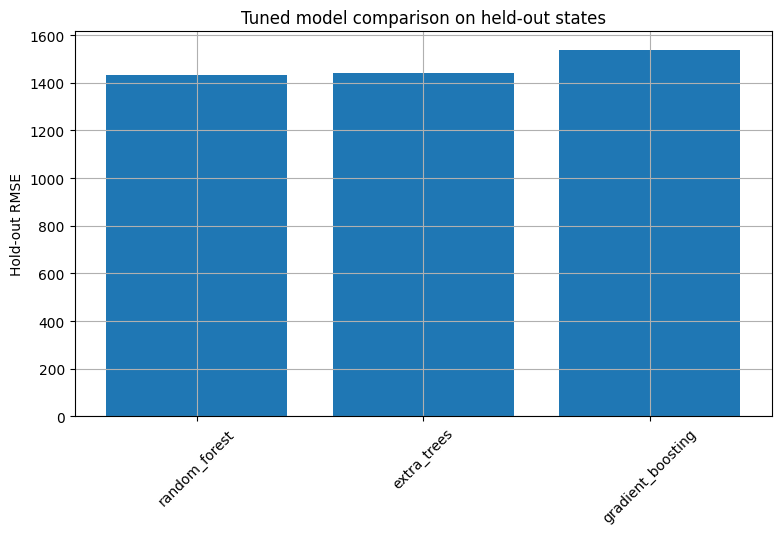

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\figures\tuned_model_comparison_notebook07.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tuned_metrics["model"], tuned_metrics["rmse"])
ax.set_ylabel("Hold-out RMSE")
ax.set_title("Tuned model comparison on held-out states")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, "figure_01")
plt.show()

fig_path = FIGURES_DIR / "tuned_model_comparison_notebook07.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Saved:", fig_path)

## 7.7 Actual versus predicted for the selected tuned model

Saved figure: reports\figures\07_hyperparameter_tuning_and_model_selection_02_figure_02.png


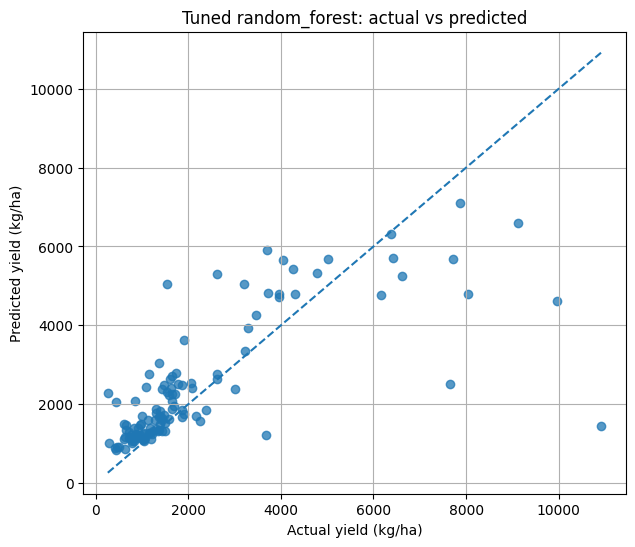

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\reports\figures\tuned_actual_vs_predicted_notebook07.png


In [8]:
best_preds = tuned_predictions.query("model == @best_model_name").copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(best_preds[TARGET], best_preds["prediction"], alpha=0.75)
lo = min(best_preds[TARGET].min(), best_preds["prediction"].min())
hi = max(best_preds[TARGET].max(), best_preds["prediction"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xlabel("Actual yield (kg/ha)")
ax.set_ylabel("Predicted yield (kg/ha)")
ax.set_title(f"Tuned {best_model_name}: actual vs predicted")
save_figure(fig, "figure_02")
plt.show()

fig_path = FIGURES_DIR / "tuned_actual_vs_predicted_notebook07.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Saved:", fig_path)

## 7.8 Inspecting largest prediction errors

In [9]:
error_table = best_preds.sort_values("abs_error", ascending=False)
display(error_table.head(25))
error_table.to_csv(TABLES_DIR / "largest_errors_tuned_model_notebook07.csv", index=False)

,state,zone,agroecological_zone,crop,season,yield_kg_ha,prediction,residual,abs_error,model
54,Nasarawa,North Central,Southern Guinea Savannah,TOMATO,major,10914.556800,1440.857822,9473.698978,9473.698978,random_forest
105,Osun,South West,Derived Savannah / Humid Forest Transition,BANANA,major,9969.026000,4628.576807,5340.449193,5340.449193,random_forest
52,Osun,South West,Derived Savannah / Humid Forest Transition,CHILLI PEPPER(SHOMBO),major,7657.712000,2517.385771,5140.326229,5140.326229,random_forest
121,Osun,South West,Derived Savannah / Humid Forest Transition,WHITEYAM,minor,1530.552000,5040.890597,-3510.338597,3510.338597,random_forest
106,Imo,South East,Humid Forest,PLANTAIN,major,8047.841000,4795.348398,3252.492602,3252.492602,random_forest
29,Imo,South East,Humid Forest,YAM,major,2628.925102,5304.968382,-2676.043280,2676.043280,random_forest
23,Lagos,South West,Mangrove / Coastal Rainforest,CASSAVA,major,9127.012000,6597.590930,2529.421070,2529.421070,random_forest
41,Bauchi,North East,Sudan Savannah,OKRO,major,3673.347800,1220.917418,2452.430382,2452.430382,random_forest
28,Enugu,South East,Derived Savannah / Humid Forest Transition,YAM,major,3708.773791,5910.005666,-2201.231875,2201.231875,random_forest
108,Osun,South West,Derived Savannah / Humid Forest Transition,PLANTAIN,major,7707.234000,5679.538284,2027.695716,2027.695716,random_forest
